In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

In [2]:
data = pd.read_csv("/content/drive/MyDrive/datascience/Mini Projects/EcoType: Forest Cover Classification/cleaned_data.csv")
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1,29.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1,29.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1,12.0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1,30.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1,29.0


In [3]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2877.778902,141.127418,11.823237,249.990496,32.558524,3313.827541,218.013359,225.156145,139.980478,3044.958105,1.186593,23.364905
std,198.061871,107.719296,6.004387,186.589869,34.623925,1687.779953,19.599968,15.155102,30.315992,1761.882341,0.656571,8.215184
min,2361.500000,0.000000,0.000000,0.000000,-59.000000,0.000000,169.500000,186.000000,64.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3389.500000,360.000000,27.000000,762.500000,117.000000,7117.000000,254.000000,254.000000,216.000000,7173.000000,4.000000,40.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           145890 non-null  float64
 1   Aspect                              145890 non-null  float64
 2   Slope                               145890 non-null  float64
 3   Horizontal_Distance_To_Hydrology    145890 non-null  float64
 4   Vertical_Distance_To_Hydrology      145890 non-null  float64
 5   Horizontal_Distance_To_Roadways     145890 non-null  float64
 6   Hillshade_9am                       145890 non-null  float64
 7   Hillshade_Noon                      145890 non-null  float64
 8   Hillshade_3pm                       145890 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  float64
 10  Cover_Type                          145890 non-null  object 
 11  Wilderness_Area           

# **Encoding the categorical columns**

In [5]:
data.select_dtypes(include=['object']).columns

Index(['Cover_Type'], dtype='object')

In [6]:
# Define Label Encoder
le = LabelEncoder()

# Fit and Transform
data['Cover_Type_Encoded'] = le.fit_transform(data["Cover_Type"])

# Drop the old string column and keep the numeric one
df = data.drop(columns=['Cover_Type'])

# Verification
mapping = dict(zip(range(len(le.classes_)), le.classes_))

print("Label Encoding Mapping:")
for code, species in mapping.items():
    print(f"{code} : {species}")


Label Encoding Mapping:
0 : Aspen
1 : Cottonwood/Willow
2 : Douglas-fir
3 : Krummholz
4 : Lodgepole Pine
5 : Ponderosa Pine
6 : Spruce/Fir


In [7]:
import pickle

# Save the newly fitted encoder to replace the old one
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


In [8]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type',
       'Cover_Type_Encoded'],
      dtype='object')

In [9]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

nominal_data = ['Wilderness_Area', 'Soil_Type']

# Initialize encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and Transform
encoded_array = ohe.fit_transform(df[nominal_data])

# 1. Clean the column names using a list comprehension
clean_columns = [col.replace('.0', '') for col in ohe.get_feature_names_out(nominal_data)]

# 2. Convert to DataFrame with clean names and original index
encoded_df = pd.DataFrame(encoded_array, columns=clean_columns, index=df.index).astype(int)

# 3. Concatenate and drop original columns
df = pd.concat([df.drop(columns=nominal_data), encoded_df], axis=1)



In [10]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type_Encoded',
       'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3',
       'Wilderness_Area_4', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3',
       'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7',
       'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11',
       'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_16',
       'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20',
       'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24',
       'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28',
       'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32',
       'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36',
       'Soil_Type_

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           145890 non-null  float64
 1   Aspect                              145890 non-null  float64
 2   Slope                               145890 non-null  float64
 3   Horizontal_Distance_To_Hydrology    145890 non-null  float64
 4   Vertical_Distance_To_Hydrology      145890 non-null  float64
 5   Horizontal_Distance_To_Roadways     145890 non-null  float64
 6   Hillshade_9am                       145890 non-null  float64
 7   Hillshade_Noon                      145890 non-null  float64
 8   Hillshade_3pm                       145890 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  float64
 10  Cover_Type_Encoded                  145890 non-null  int64  
 11  Wilderness_Area_1         

In [12]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0,0,0,0,0,0,0,0,0,0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0,0,0,0,0,0,0,0,0,0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0,0,0,0,0,0,0,0,0,0
3,2785.0,155.0,18.0,242.0,117.0,3090.0,238.0,238.0,122.0,6211.0,...,0,0,0,0,0,0,0,0,0,0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0,0,0,0,0,0,0,0,0,0


# **Handling Skewness**

In [13]:
df.select_dtypes(include=['float']).columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points'],
      dtype='object')

In [14]:
columns = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points']
skewness = data[columns].skew()
skewness

,0
Elevation,-0.340370
Aspect,0.689432
Slope,0.621361
Horizontal_Distance_To_Hydrology,0.792349
Vertical_Distance_To_Hydrology,0.861265
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_9am,-0.740409
Hillshade_Noon,-0.505363
Hillshade_3pm,-0.001189
Horizontal_Distance_To_Fire_Points,0.365249


# **Visualizing the skewness**

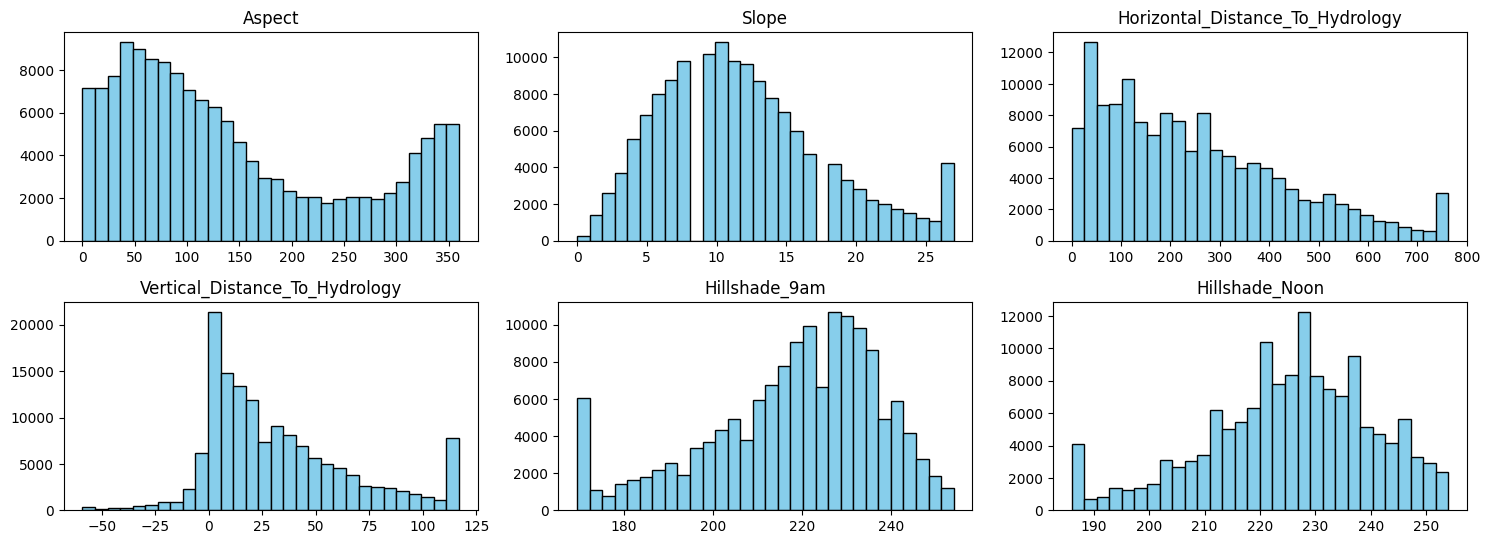

In [15]:
# Select numerical columns with high skewness (absolute skewness > 0.5)
skewed_cols = skewness[abs(skewness) > 0.5].index

# Plot histograms before transformation
plt.figure(figsize=(15, 8))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(3, 3, i)  # Adjust grid size as needed
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col}")
plt.tight_layout()
plt.show()

# **Apply Log Transform to Positively Skewed Columns**

In [16]:
skewed_cols = skewness[(skewness) > 0.5].index
skewed_cols

Index(['Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology'],
      dtype='object')

In [17]:
# Columns that are positively skewed
pos_skewed_cols = ['Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology']

from sklearn.preprocessing import PowerTransformer

# Initialize the transformer (method='yeo-johnson' is the default)
pt = PowerTransformer(method='yeo-johnson')

# Apply it to your skewed columns
# Note: It expects a 2D array, so we use [[col]]
df[pos_skewed_cols] = pt.fit_transform(df[pos_skewed_cols])
df[pos_skewed_cols].skew()

,0
Aspect,-0.099594
Slope,-0.020527
Horizontal_Distance_To_Hydrology,-0.169816
Vertical_Distance_To_Hydrology,0.087352


# **Apply Box-Cox to Negatively Skewed Columns**

In [18]:
skewed_cols = skewness[(skewness) < -0.5].index
skewed_cols

Index(['Hillshade_9am', 'Hillshade_Noon'], dtype='object')

In [19]:
# Columns that are negatively skewed
neg_skewed_cols = ['Hillshade_9am', 'Hillshade_Noon']
from scipy import stats

# Apply Box-Cox to the negatively skewed columns
for col in neg_skewed_cols:
    data[col], _ = stats.boxcox(df[col] + 1)
data[neg_skewed_cols].skew()

,0
Hillshade_9am,-0.097810
Hillshade_Noon,-0.040928


# **Scaling Continuous Variables**

In [20]:
from sklearn.preprocessing import StandardScaler

# List of columns to scale
cols_to_scale = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                 'Horizontal_Distance_To_Fire_Points']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


In [21]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40
0,-1.422686,-0.765024,-1.756890,0.258124,-0.915049,-1.661258,0.152380,0.451589,0.264532,1.835567,...,0,0,0,0,0,0,0,0,0,0
1,-1.452980,-0.687865,-2.084479,0.024593,-1.217221,-1.732357,0.101360,0.649543,0.363490,1.804918,...,0,0,0,0,0,0,0,0,0,0
2,-0.372506,0.232573,-0.364570,0.305943,0.930837,-0.079292,0.815649,0.847497,-0.164286,1.745890,...,0,0,0,0,0,0,0,0,0,0
3,-0.468436,0.366744,1.034132,0.179560,2.181810,-0.132617,1.019732,0.847497,-0.593104,1.796972,...,0,0,0,0,0,0,0,0,0,0
4,-1.427735,-0.863856,-2.084479,-0.317796,-0.959961,-1.731765,0.101360,0.583558,0.330504,1.774836,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40
count,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,1.458900e+05,...,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,-5.610701e-17,1.207859e-17,-3.701504e-17,2.026087e-17,2.415719e-17,-2.805351e-17,-3.865150e-16,8.743343e-16,1.768929e-16,-8.727758e-17,...,0.002276,0.004730,0.004222,0.000151,0.000699,0.000069,0.000233,0.005504,0.008294,0.005045
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,0.047650,0.068609,0.064843,0.012279,0.026432,0.008279,0.015264,0.073986,0.090693,0.070848
min,-2.606664e+00,-2.429973e+00,-2.998353e+00,-2.178204e+00,-4.710900e+00,-1.963431e+00,-2.475184e+00,-2.583703e+00,-2.506292e+00,-1.728247e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.602954e-01,-7.182124e-01,-7.604614e-01,-7.307649e-01,-6.634273e-01,-8.684974e-01,-5.619089e-01,-6.041646e-01,-6.260901e-01,-8.155840e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.576336e-01,-5.693109e-02,-8.979499e-03,2.459282e-02,-1.801091e-01,6.290679e-02,2.034011e-01,5.568144e-02,6.439382e-04,-1.884117e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.372833e-01,8.192963e-01,6.175810e-01,7.163150e-01,5.749834e-01,8.053047e-01,7.136077e-01,7.155275e-01,6.273780e-01,8.133612e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.583652e+00,1.623157e+00,2.106662e+00,2.027918e+00,2.181810e+00,2.253366e+00,1.836062e+00,1.903250e+00,2.507580e+00,2.342981e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type_Encoded',
       'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3',
       'Wilderness_Area_4', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3',
       'Soil_Type_4', 'Soil_Type_5', 'Soil_Type_6', 'Soil_Type_7',
       'Soil_Type_8', 'Soil_Type_9', 'Soil_Type_10', 'Soil_Type_11',
       'Soil_Type_12', 'Soil_Type_13', 'Soil_Type_14', 'Soil_Type_16',
       'Soil_Type_17', 'Soil_Type_18', 'Soil_Type_19', 'Soil_Type_20',
       'Soil_Type_21', 'Soil_Type_22', 'Soil_Type_23', 'Soil_Type_24',
       'Soil_Type_25', 'Soil_Type_26', 'Soil_Type_27', 'Soil_Type_28',
       'Soil_Type_29', 'Soil_Type_30', 'Soil_Type_31', 'Soil_Type_32',
       'Soil_Type_33', 'Soil_Type_34', 'Soil_Type_35', 'Soil_Type_36',
       'Soil_Type_

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare Features (X) and Target (y)
# Drop the target and handle the infinity/NaN values from your previous log transformations
X = df.drop(columns=['Cover_Type_Encoded']).replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['Cover_Type_Encoded']

# 2. Train the Random Forest model
# n_jobs=-1 uses all CPU cores (important for large datasets like Forest Cover)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 3. Create Feature Importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# 4. Sort and Display
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Show the top results
feature_importance_df


,Feature,Importance
0,Elevation,0.237147
5,Horizontal_Distance_To_Roadways,0.137605
9,Horizontal_Distance_To_Fire_Points,0.123716
3,Horizontal_Distance_To_Hydrology,0.063226
4,Vertical_Distance_To_Hydrology,0.058065
1,Aspect,0.046360
8,Hillshade_3pm,0.040874
7,Hillshade_Noon,0.040435
10,Wilderness_Area_1,0.039052
6,Hillshade_9am,0.037807


# **Bar Graph for Feature Importance**

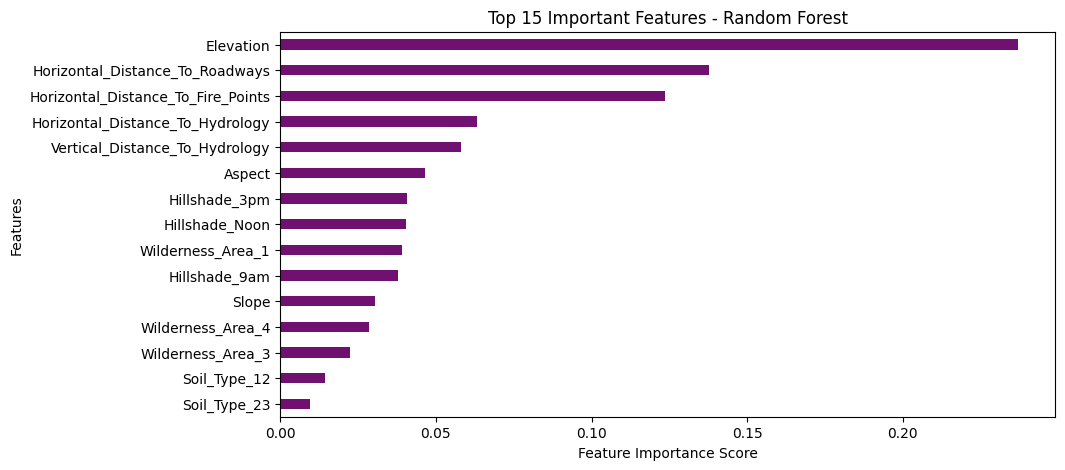

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(x=feature_importance_df['Importance'][:15], y=feature_importance_df['Feature'][:15], color='purple', width=0.4)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features - Random Forest")
plt.show()

In [26]:
feature_importance_df['Feature'][:15].tolist()

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Aspect',
 'Hillshade_3pm',
 'Hillshade_Noon',
 'Wilderness_Area_1',
 'Hillshade_9am',
 'Slope',
 'Wilderness_Area_4',
 'Wilderness_Area_3',
 'Soil_Type_12',
 'Soil_Type_23']

In [27]:
top_15 = ['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Aspect',
 'Hillshade_3pm',
 'Hillshade_Noon',
 'Wilderness_Area_1',
 'Hillshade_9am',
 'Slope',
 'Wilderness_Area_4',
 'Wilderness_Area_3',
 'Soil_Type_12',
 'Soil_Type_23',
  'Cover_Type_Encoded']

filtered1 = df[top_15] # original data

filtered1.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Aspect,Hillshade_3pm,Hillshade_Noon,Wilderness_Area_1,Hillshade_9am,Slope,Wilderness_Area_4,Wilderness_Area_3,Soil_Type_12,Soil_Type_23,Cover_Type_Encoded
0,-1.422686,-1.661258,1.835567,0.258124,-0.915049,-0.765024,0.264532,0.451589,1,0.152380,-1.756890,0,0,0,0,0
1,-1.452980,-1.732357,1.804918,0.024593,-1.217221,-0.687865,0.363490,0.649543,1,0.101360,-2.084479,0,0,0,0,0
2,-0.372506,-0.079292,1.745890,0.305943,0.930837,0.232573,-0.164286,0.847497,1,0.815649,-0.364570,0,0,1,0,4
3,-0.468436,-0.132617,1.796972,0.179560,2.181810,0.366744,-0.593104,0.847497,1,1.019732,1.034132,0,0,0,0,4
4,-1.427735,-1.731765,1.774836,-0.317796,-0.959961,-0.863856,0.330504,0.583558,1,0.101360,-2.084479,0,0,0,0,0


In [28]:
filtered1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 16 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           145890 non-null  float64
 1   Horizontal_Distance_To_Roadways     145890 non-null  float64
 2   Horizontal_Distance_To_Fire_Points  145890 non-null  float64
 3   Horizontal_Distance_To_Hydrology    145890 non-null  float64
 4   Vertical_Distance_To_Hydrology      145890 non-null  float64
 5   Aspect                              145890 non-null  float64
 6   Hillshade_3pm                       145890 non-null  float64
 7   Hillshade_Noon                      145890 non-null  float64
 8   Wilderness_Area_1                   145890 non-null  int64  
 9   Hillshade_9am                       145890 non-null  float64
 10  Slope                               145890 non-null  float64
 11  Wilderness_Area_4         

In [29]:
filtered1.to_csv("filtered_data.csv",index=False)